In [ ]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/loan_approval.csv',header=None)

In [ ]:
from mlxtend.preprocessing import TransactionEncoder

# Consolidate each transaction into a single list of items, removing NaN values
transactions = df.apply(lambda row: row.dropna().tolist(), axis = 1).tolist()

# Initialize TransactionEncoder
encoder = TransactionEncoder()

# Fit and transform the transactions data
transaction_matrix = encoder.fit_transform(transactions)

# Convert to DataFrame
transaction_df = pd.DataFrame(transaction_matrix, columns = encoder.columns_)
transaction_df

,1-2,18-25,26-35,36-50,51+,Age_Group,Credit_Average,Credit_Excellent,Credit_Good,Credit_Poor,...,Marital_Status,Marital_Widowed,Shopping_Balanced,Shopping_Frugal,Shopping_Habits,Shopping_Luxury,Travel_Frequently,Travel_Habits,Travel_Occasionally,Travel_Rarely
0,False,False,False,False,False,True,False,False,False,False,...,True,False,False,False,True,False,False,True,False,False
1,False,True,False,False,False,False,False,False,True,False,...,False,False,False,False,False,True,True,False,False,False
2,False,False,False,False,True,False,False,False,False,True,...,False,False,False,True,False,False,True,False,False,False
3,False,False,False,False,True,False,False,True,False,False,...,False,False,True,False,False,False,False,False,True,False
4,False,False,True,False,False,False,False,False,False,True,...,False,True,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,False,True,False,False,False,False,False,True,False,False,...,False,False,True,False,False,False,True,False,False,False
997,False,False,False,False,True,False,False,False,False,True,...,False,True,False,True,False,False,False,False,False,True
998,False,False,False,True,False,False,True,False,False,False,...,False,False,False,True,False,False,True,False,False,False
999,True,False,False,True,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,True


In [ ]:
from mlxtend.frequent_patterns import fpgrowth, association_rules

# Apply the FPGrowth Algorithm
frequent_itemsets = fpgrowth(transaction_df, min_support = 0.1, use_colnames = True)
print(frequent_itemsets)

      support                                      itemsets
0    0.969031                                 (Loan_Denied)
1    0.338661                             (Dependents_None)
2    0.334665                                 (Fitness_Low)
3    0.330669                                (Health_Acute)
4    0.326673                           (Travel_Frequently)
..        ...                                           ...
302  0.118881   (Loan_Denied, Dependents_3+, Travel_Rarely)
303  0.112887    (Loan_Denied, Fitness_High, Travel_Rarely)
304  0.121878  (Loan_Denied, Health_Healthy, Travel_Rarely)
305  0.109890     (Loan_Denied, Travel_Rarely, Fitness_Low)
306  0.215784                          (Loan_Denied, 36-50)

[307 rows x 2 columns]


In [ ]:
rules = association_rules(frequent_itemsets, num_itemsets = len(transaction_df), metric = "confidence", min_threshold = 0.1)

rules.loc[:, :'lift'].to_csv('rules.csv')
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Loan_Denied),(Dependents_None),0.969031,0.338661,0.316683,0.326804,0.964988,1.0,-0.011490,0.982387,-0.539503,0.319556,-0.017929,0.630954
1,(Dependents_None),(Loan_Denied),0.338661,0.969031,0.316683,0.935103,0.964988,1.0,-0.011490,0.477205,-0.052009,0.319556,-1.095537,0.630954
2,(Shopping_Frugal),(Dependents_None),0.344655,0.338661,0.113886,0.330435,0.975709,1.0,-0.002835,0.987714,-0.036599,0.200000,-0.012439,0.333359
3,(Dependents_None),(Shopping_Frugal),0.338661,0.344655,0.113886,0.336283,0.975709,1.0,-0.002835,0.987386,-0.036279,0.200000,-0.012775,0.333359
4,(Travel_Occasionally),(Dependents_None),0.341658,0.338661,0.126873,0.371345,1.096508,1.0,0.011167,1.051990,0.133691,0.229242,0.049421,0.372988
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
971,(Loan_Denied),"(Travel_Rarely, Fitness_Low)",0.969031,0.109890,0.109890,0.113402,1.031959,1.0,0.003403,1.003961,1.000000,0.113402,0.003946,0.556701
972,(Travel_Rarely),"(Loan_Denied, Fitness_Low)",0.330669,0.334665,0.109890,0.332326,0.993011,1.0,-0.000773,0.996497,-0.010406,0.197842,-0.003516,0.330342
973,(Fitness_Low),"(Loan_Denied, Travel_Rarely)",0.334665,0.330669,0.109890,0.328358,0.993011,1.0,-0.000773,0.996559,-0.010468,0.197842,-0.003453,0.330342
974,(Loan_Denied),(36-50),0.969031,0.220779,0.215784,0.222680,1.008611,1.0,0.001842,1.002446,0.275687,0.221538,0.002440,0.600028


In [ ]:
approval_rules = rules[rules['consequents'] == {'Loan_Granted'}]

if not approval_rules.empty:
    most_pressing_approval_rule = approval_rules.sort_values(by='confidence', ascending=False).iloc[0]

    print("The most pressing association rule for loan approval is:")
    print(most_pressing_approval_rule)
else:
    print("No association rules found for loan approval with the given minimum support and confidence.")

No association rules found for loan approval with the given minimum support and confidence.


In [ ]:
most_pressing_rule = rules.sort_values(by='confidence', ascending=False).iloc[0]

print("The most pressing association rule is:")
print(most_pressing_rule)

The most pressing association rule is:
antecedents           (Travel_Rarely, Fitness_Low)
consequents                          (Loan_Denied)
antecedent support                         0.10989
consequent support                        0.969031
support                                    0.10989
confidence                                     1.0
lift                                      1.031959
representativity                               1.0
leverage                                  0.003403
conviction                                     inf
zhangs_metric                             0.034792
jaccard                                   0.113402
certainty                                      1.0
kulczynski                                0.556701
Name: 970, dtype: object


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/personnel_data.csv')
df

,EmployeeID,Age,Experience,EducationLevel,Salary,JobSatisfaction,Department,ProjectsHandled,PromotionLast5Years
0,1,50,1,2,33.07,3,5,10,0
1,2,36,4,1,19.37,7,1,11,0
2,3,29,28,1,52.64,8,1,5,1
3,4,42,18,3,60.37,10,4,8,0
4,5,40,7,1,28.94,6,3,15,0
...,...,...,...,...,...,...,...,...,...
495,496,59,7,2,35.53,2,1,0,0
496,497,28,0,2,31.77,8,1,5,0
497,498,34,2,2,33.01,5,3,5,0
498,499,30,23,2,52.72,7,5,20,0


In [ ]:
df_cleaned = df.drop(['EmployeeID'], axis=1)
df_cleaned.head()

,Age,Experience,EducationLevel,Salary,JobSatisfaction,Department,ProjectsHandled,PromotionLast5Years
0,50,1,2,33.07,3,5,10,0
1,36,4,1,19.37,7,1,11,0
2,29,28,1,52.64,8,1,5,1
3,42,18,3,60.37,10,4,8,0
4,40,7,1,28.94,6,3,15,0


In [ ]:
# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_cleaned)
scaled_df = pd.DataFrame(scaled_data, columns=df_cleaned.columns)

# Get specific values for questions 2 and 3
salary_125 = scaled_df.loc[124, 'Salary']
experience_130 = scaled_df.loc[129, 'Experience']

print(salary_125)
print(experience_130)

0.11263172953612322
-1.2543169481899312


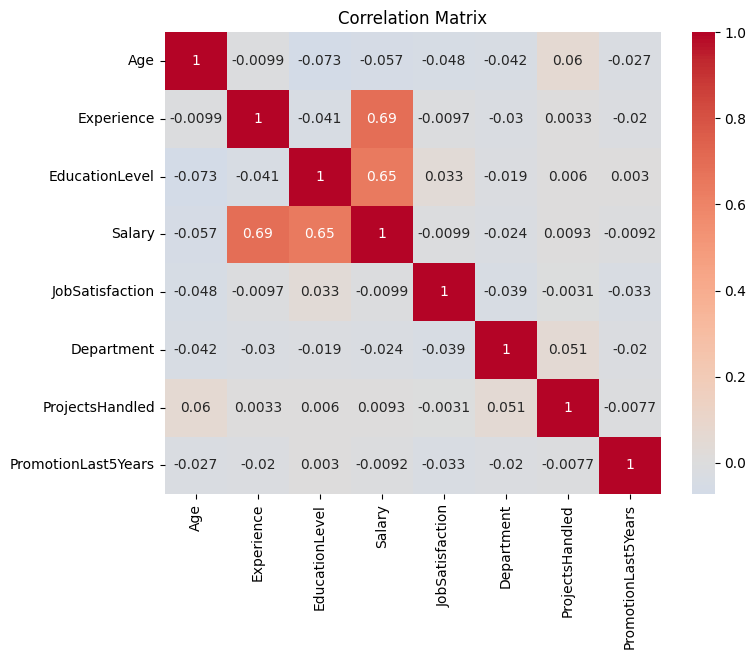

Highly correlated pairs (|r| > 0.66):
Salary - Experience: 0.686

Variables to eliminate based on correlation threshold: ['Experience']


In [ ]:
# Calculate correlation matrix
corr_matrix = df_cleaned.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# Find highly correlated variables (absolute value > 0.66)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.66:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j],
                            corr_matrix.iloc[i, j]))

print("Highly correlated pairs (|r| > 0.66):")
variables_to_eliminate = set()
for pair in high_corr:
    print(f"{pair[0]} - {pair[1]}: {pair[2]:.3f}")
    variables_to_eliminate.add(pair[1])


if variables_to_eliminate:
    print(f"\nVariables to eliminate based on correlation threshold: {list(variables_to_eliminate)}")
else:
    print("\nNo variables to eliminate based on the correlation threshold.")

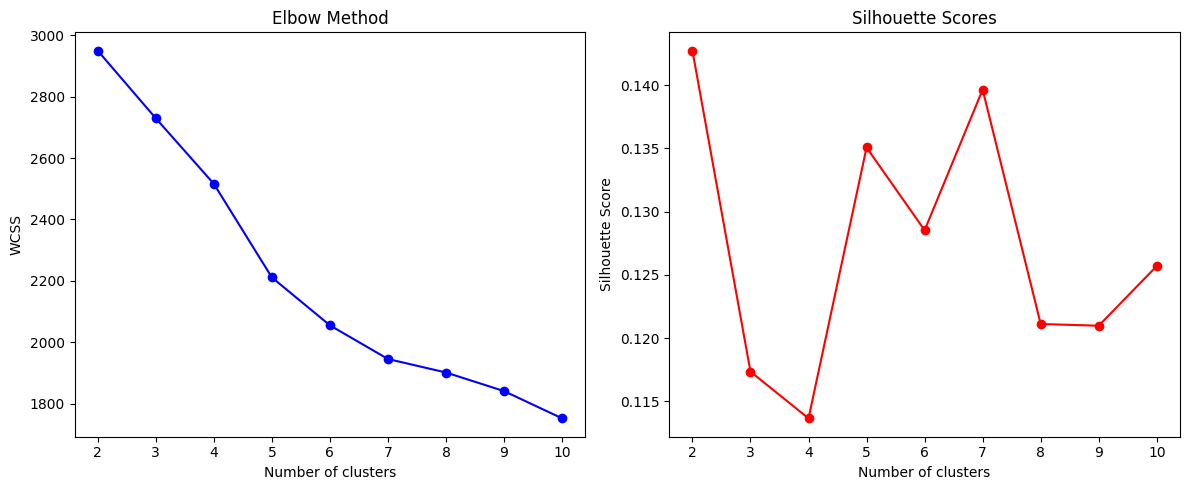

Optimal clusters by elbow method: 5
Optimal clusters by silhouette score: 3


In [ ]:
# Remove highly correlated variable (Experience)
df_final = df_cleaned.drop(['Experience'], axis=1)

# Scale the final data
scaler_final = StandardScaler()
scaled_final = scaler_final.fit_transform(df_final)
scaled_final_df = pd.DataFrame(scaled_final, columns=df_final.columns)

# Determine optimal k using elbow method and silhouette scores WITH random_state=101 and n_init='auto'
wcss = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=101, n_init='auto')
    kmeans.fit(scaled_final_df)
    wcss.append(kmeans.inertia_)

    if k > 1:
        silhouette_scores.append(silhouette_score(scaled_final_df, kmeans.labels_))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, 'bo-')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, 'ro-')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.tight_layout()
plt.show()

optimal_k_elbow = 5
optimal_k_silhouette = range(2, 11)[np.argmax(silhouette_scores)] + 1

print(f"Optimal clusters by elbow method: {optimal_k_elbow}")
print(f"Optimal clusters by silhouette score: {optimal_k_silhouette}")

Cluster Statistics (Salary and Age means):
            Salary        Age
Cluster                      
0        45.042314  45.628099
1        63.834607  31.584270
2        69.661778  44.711111
3        38.834356  41.891089
4        52.895657  41.151515


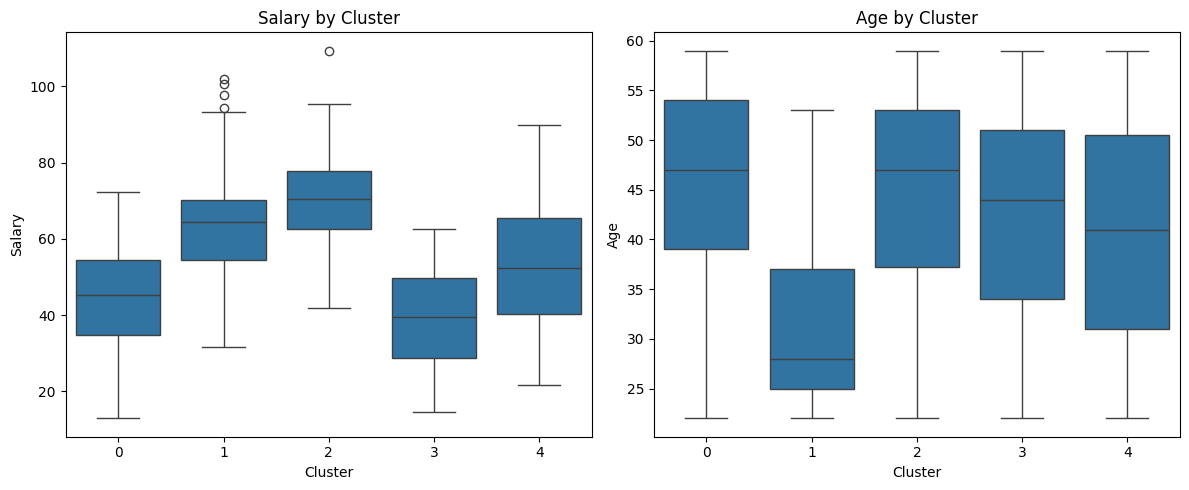

In [ ]:
kmeans = KMeans(n_clusters=optimal_k_elbow, random_state=101, n_init='auto')
clusters = kmeans.fit_predict(scaled_final_df)

df_final['Cluster'] = clusters

cluster_stats = df_final.groupby('Cluster')[['Salary', 'Age']].mean()
print("Cluster Statistics (Salary and Age means):")
print(cluster_stats)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='Cluster', y='Salary', data=df_final)
plt.title('Salary by Cluster')

plt.subplot(1, 2, 2)
sns.boxplot(x='Cluster', y='Age', data=df_final)
plt.title('Age by Cluster')
plt.tight_layout()
plt.show()

In [ ]:
cluster_305 = clusters[304]
print(f"8. Data 305 belongs to cluster: {cluster_305}")

8. Data 305 belongs to cluster: 2


In [ ]:
centroids_scaled = kmeans.cluster_centers_

age_idx = list(scaled_final_df.columns).index('Age')
salary_idx = list(scaled_final_df.columns).index('Salary')

age_salary_centroids = centroids_scaled[:, [age_idx, salary_idx]]
print("Centroids of Age and Salary (scaled):")
for i, centroid in enumerate(age_salary_centroids):
    print(f"Cluster {i}: [{centroid[0]:.2f}, {centroid[1]:.2f}]")

Centroids of Age and Salary (scaled):
Cluster 0: [0.39, -0.45]
Cluster 1: [-0.88, 0.59]
Cluster 2: [0.31, 0.92]
Cluster 3: [0.05, -0.79]
Cluster 4: [-0.02, -0.01]


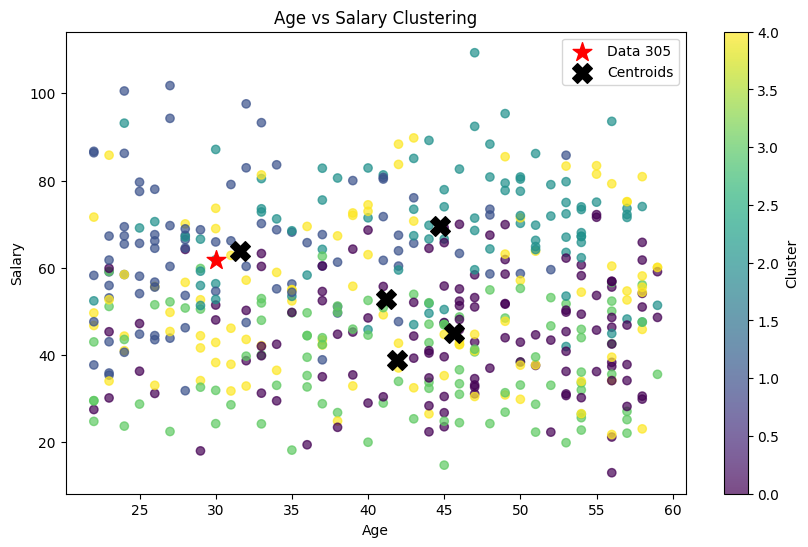

In [ ]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_final['Age'], df_final['Salary'], c=clusters, cmap='viridis', alpha=0.7)
plt.scatter(df_final.loc[304, 'Age'], df_final.loc[304, 'Salary'],
           marker='*', s=200, c='red', label='Data 305')

centroids_original = scaler_final.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids_original[:, age_idx],
           centroids_original[:, salary_idx],
           marker='X', s=200, c='black', label='Centroids')

plt.xlabel('Age')
plt.ylabel('Salary')
plt.title('Age vs Salary Clustering')
plt.legend()
plt.colorbar(scatter, label='Cluster')
plt.show()

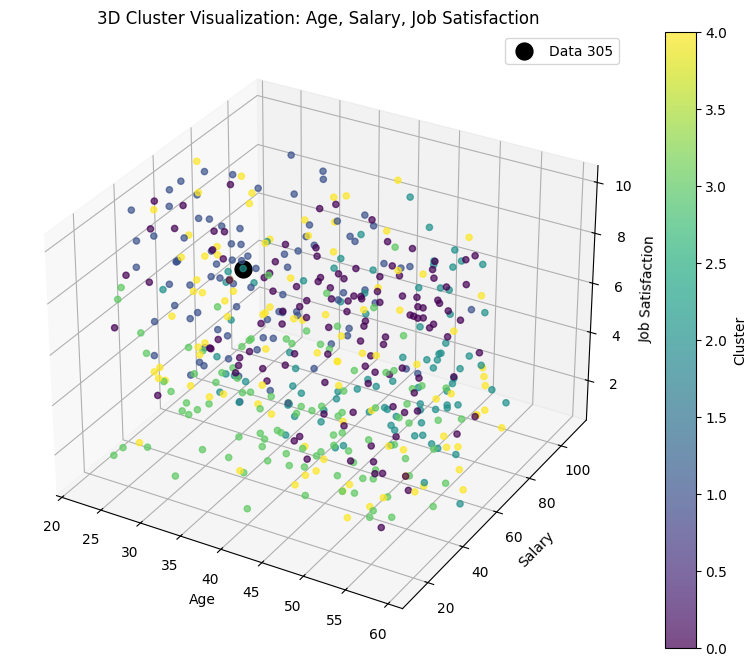

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

js_idx = list(df_final.columns).index('JobSatisfaction')

scatter = ax.scatter(df_final['Age'], df_final['Salary'], df_final['JobSatisfaction'],
                   c=clusters, cmap='viridis', alpha=0.7)

ax.scatter(df_final.loc[304, 'Age'], df_final.loc[304, 'Salary'],
          df_final.loc[304, 'JobSatisfaction'],
          s=200, c='black', marker='o', edgecolors='white', label='Data 305')

ax.set_xlabel('Age')
ax.set_ylabel('Salary')
ax.set_zlabel('Job Satisfaction')
ax.set_title('3D Cluster Visualization: Age, Salary, Job Satisfaction')
plt.legend()
plt.colorbar(scatter, label='Cluster')
plt.show()

In [ ]:
import plotly.express as px

fig = px.scatter_3d(
    df_final,
    x='Age',
    y='Salary',
    z='JobSatisfaction',
    color=clusters,
    opacity=0.7
)

# Highlight point 305
fig.add_scatter3d(
    x=[df_final.loc[304, 'Age']],
    y=[df_final.loc[304, 'Salary']],
    z=[df_final.loc[304, 'JobSatisfaction']],
    mode='markers',
    marker=dict(size=10, color='black', symbol='circle'),
    name='Data 305'
)

fig.update_layout(
    title='3D Cluster Visualization: Age, Salary, Job Satisfaction',
    scene=dict(
        xaxis_title='Age',
        yaxis_title='Salary',
        zaxis_title='Job Satisfaction'
    )
)

fig.show()
